In [31]:
import requests
import pandas as pd

limit = 30
skip = 0
listpd = []

while True:
    url = f'https://dummyjson.com/users?limit={limit}&skip={skip}'
    response = requests.get(url)
    data = response.json()['users']

    listpd.append(pd.DataFrame(data))

    total = response.json()['total']
    skip += limit

    if skip >= total:
        break

users = pd.concat(listpd, ignore_index=True)

print(users.head())

users.to_csv('users.csv', index=False)
print("Saved to users.csv")

   id firstName  lastName maidenName  age  gender  \
0   1     Emily   Johnson      Smith   29  female   
1   2   Michael  Williams              36    male   
2   3    Sophia     Brown              43  female   
3   4     James     Davis              46    male   
4   5      Emma    Miller    Johnson   31  female   

                              email             phone  username      password  \
0     emily.johnson@x.dummyjson.com  +81 965-431-3024    emilys    emilyspass   
1  michael.williams@x.dummyjson.com  +49 258-627-6644  michaelw  michaelwpass   
2      sophia.brown@x.dummyjson.com  +81 210-652-2785   sophiab   sophiabpass   
3       james.davis@x.dummyjson.com  +49 614-958-9364    jamesd    jamesdpass   
4       emma.miller@x.dummyjson.com  +91 759-776-1614     emmaj     emmajpass   

   ...                                            address         macAddress  \
0  ...  {'address': '626 Main Street', 'city': 'Phoeni...  47:fa:41:18:ec:eb   
1  ...  {'address': '385 Fifth Str

In [32]:
print("Shape:", users.shape)

Shape: (208, 28)


In [33]:
print(users.columns.tolist())

['id', 'firstName', 'lastName', 'maidenName', 'age', 'gender', 'email', 'phone', 'username', 'password', 'birthDate', 'image', 'bloodGroup', 'height', 'weight', 'eyeColor', 'hair', 'ip', 'address', 'macAddress', 'university', 'bank', 'company', 'ein', 'ssn', 'userAgent', 'crypto', 'role']


In [34]:
print(users.dtypes)

id              int64
firstName      object
lastName       object
maidenName     object
age             int64
gender         object
email          object
phone          object
username       object
password       object
birthDate      object
image          object
bloodGroup     object
height        float64
weight        float64
eyeColor       object
hair           object
ip             object
address        object
macAddress     object
university     object
bank           object
company        object
ein            object
ssn            object
userAgent      object
crypto         object
role           object
dtype: object


In [35]:
print(users.isnull().sum())

id            0
firstName     0
lastName      0
maidenName    0
age           0
gender        0
email         0
phone         0
username      0
password      0
birthDate     0
image         0
bloodGroup    0
height        0
weight        0
eyeColor      0
hair          0
ip            0
address       0
macAddress    0
university    0
bank          0
company       0
ein           0
ssn           0
userAgent     0
crypto        0
role          0
dtype: int64


In [36]:
print(users.describe())


               id         age      height      weight
count  208.000000  208.000000  208.000000  208.000000
mean   104.500000   33.139423  175.720240   75.038606
std     60.188592    5.544269   14.119984   14.090775
min      1.000000   23.000000  150.250000   50.100000
25%     52.750000   29.000000  164.187500   62.547500
50%    104.500000   32.000000  177.430000   75.985000
75%    156.250000   36.000000  186.960000   86.992500
max    208.000000   46.000000  199.810000   99.540000


In [37]:
print(users['gender'].value_counts())
print(users['bloodGroup'].value_counts())
print(users['eyeColor'].value_counts())
print(users['role'].value_counts())

gender
female    106
male      102
Name: count, dtype: int64
bloodGroup
O-     31
B-     31
AB+    29
AB-    29
B+     25
O+     22
A+     21
A-     20
Name: count, dtype: int64
eyeColor
Brown     35
Hazel     34
Green     28
Blue      24
Gray      24
Violet    22
Red       21
Amber     20
Name: count, dtype: int64
role
user         193
moderator     10
admin          5
Name: count, dtype: int64


In [38]:
users['country'] = users['address'].apply(lambda x: x['country'])
users['city'] = users['address'].apply(lambda x: x['city'])

In [39]:
print(users['country'].value_counts())

country
United States    208
Name: count, dtype: int64


In [40]:
users['age'].fillna(users['age'].mean(), inplace=True)
users['height'].fillna(users['height'].mean(), inplace=True)
users['weight'].fillna(users['weight'].mean(), inplace=True)

C:\Users\Legion\AppData\Local\Temp\ipykernel_27172\1998576634.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  users['age'].fillna(users['age'].mean(), inplace=True)
C:\Users\Legion\AppData\Local\Temp\ipykernel_27172\1998576634.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


In [41]:
print("Average age:", users['age'].mean())

Average age: 33.13942307692308


In [42]:
print(users.groupby('gender')['age'].mean())

gender
female    31.377358
male      34.970588
Name: age, dtype: float64


In [43]:
print(users['gender'].value_counts())

gender
female    106
male      102
Name: count, dtype: int64


In [44]:
print(users['city'].value_counts().head(10))

city
Phoenix         17
Dallas          15
Jacksonville    14
Los Angeles     14
Seattle         12
San Jose        11
Charlotte       11
Philadelphia    11
Chicago         11
Columbus        11
Name: count, dtype: int64


In [45]:
print("Average Height:", users['height'].mean())
print("Average Weight:", users['weight'].mean())

Average Height: 175.72024038461538
Average Weight: 75.03860576923077


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
sns.set_context("talk")  
plt.rcParams["figure.figsize"] = (8,5)


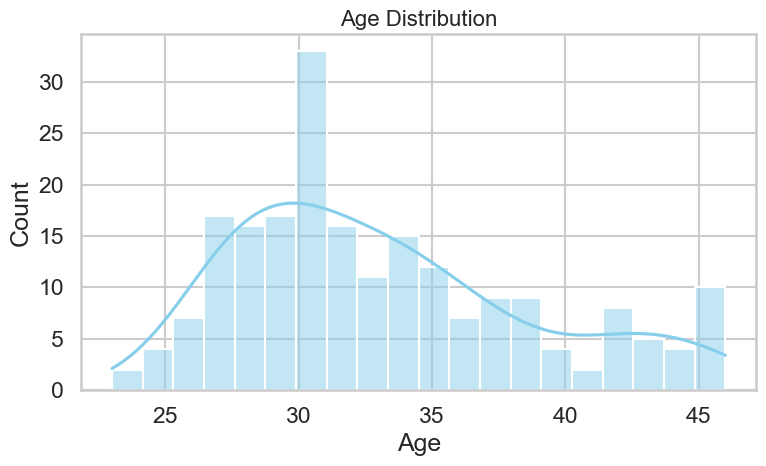

In [49]:
plt.figure()

sns.histplot(users['age'], bins=20, kde=True, color='skyblue')

plt.title("Age Distribution", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.show()


C:\Users\Legion\AppData\Local\Temp\ipykernel_27172\2090446604.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=users, palette='pastel')


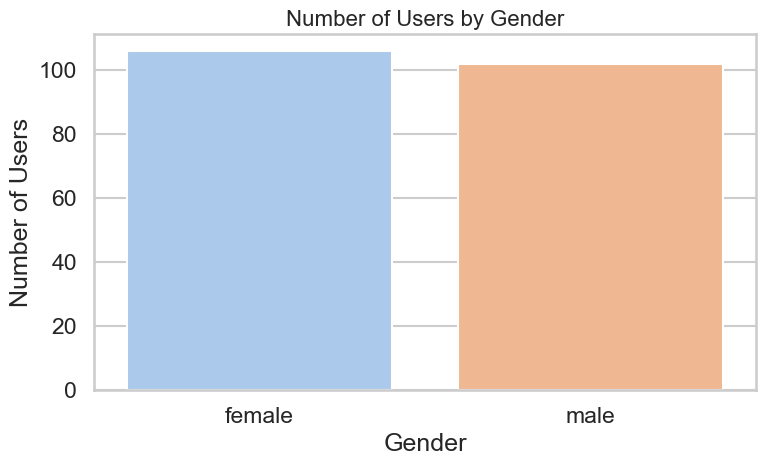

In [50]:
plt.figure()

sns.countplot(x='gender', data=users, palette='pastel')

plt.title("Number of Users by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()


C:\Users\Legion\AppData\Local\Temp\ipykernel_27172\2741962370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='gender', y='age', data=users, palette='viridis')


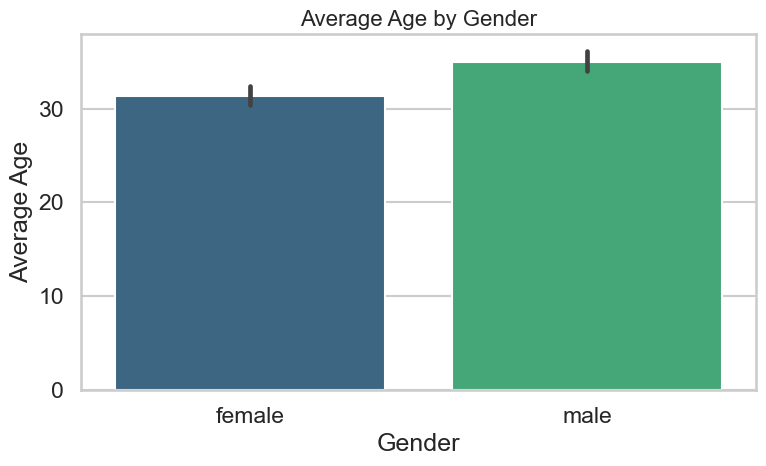

In [51]:
plt.figure()

sns.barplot(x='gender', y='age', data=users, palette='viridis')

plt.title("Average Age by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Average Age")

plt.tight_layout()
plt.show()


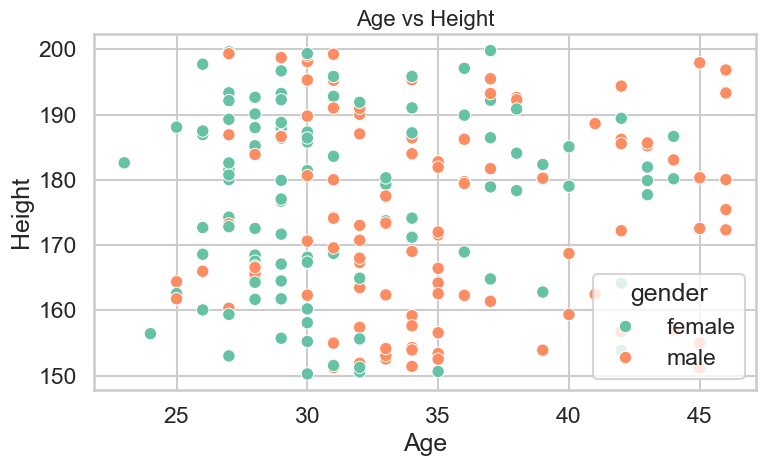

In [52]:
plt.figure()

sns.scatterplot(
    x='age',
    y='height',
    data=users,
    hue='gender',
    palette='Set2',
    s=80
)

plt.title("Age vs Height", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Height")

plt.tight_layout()
plt.show()


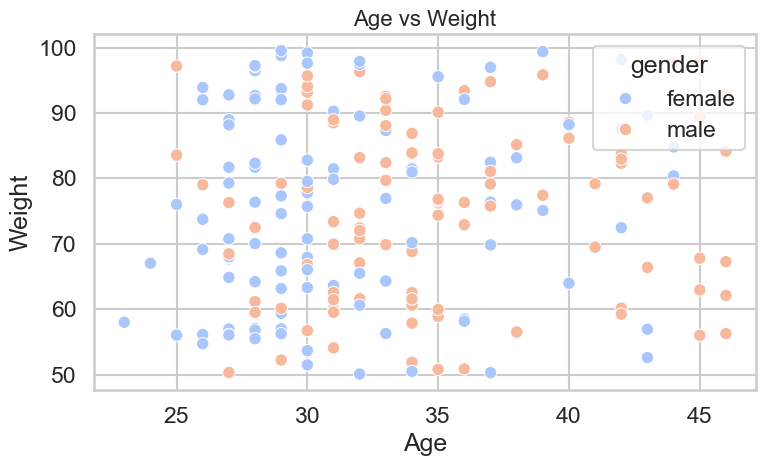

In [53]:
plt.figure()

sns.scatterplot(
    x='age',
    y='weight',
    data=users,
    hue='gender',
    palette='coolwarm',
    s=80
)

plt.title("Age vs Weight", fontsize=16)
plt.xlabel("Age")
plt.ylabel("Weight")

plt.tight_layout()
plt.show()


C:\Users\Legion\AppData\Local\Temp\ipykernel_27172\286501992.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


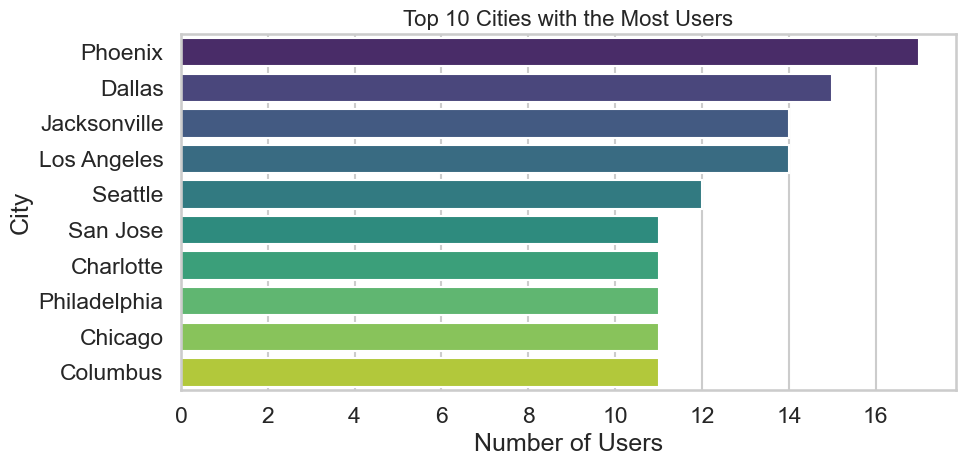

In [56]:
top_cities = users['city'].value_counts().head(10)
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    palette="viridis"
)

plt.title("Top 10 Cities with the Most Users", fontsize=16)
plt.xlabel("Number of Users")
plt.ylabel("City")

plt.tight_layout()
plt.show()


C:\Users\Legion\AppData\Local\Temp\ipykernel_27172\461944186.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=avg_data, palette="coolwarm")


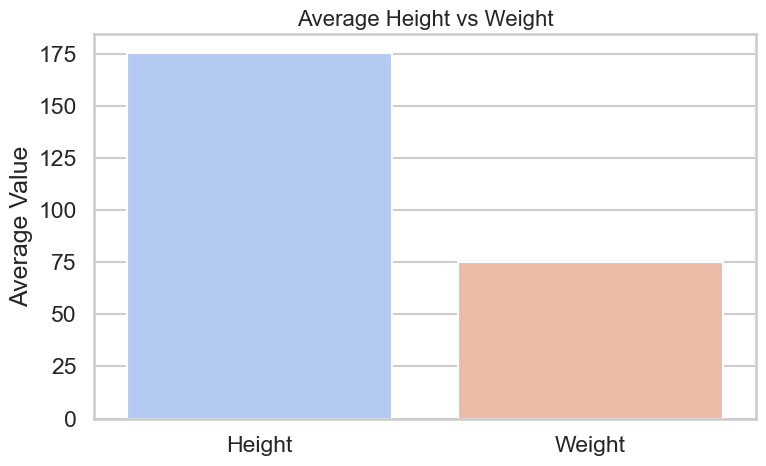

In [57]:
avg_height = users['height'].mean()
avg_weight = users['weight'].mean()
avg_data = [avg_height, avg_weight]
labels = ['Height', 'Weight']

plt.figure()

sns.barplot(x=labels, y=avg_data, palette="coolwarm")

plt.title("Average Height vs Weight", fontsize=16)
plt.ylabel("Average Value")

plt.tight_layout()
plt.show()


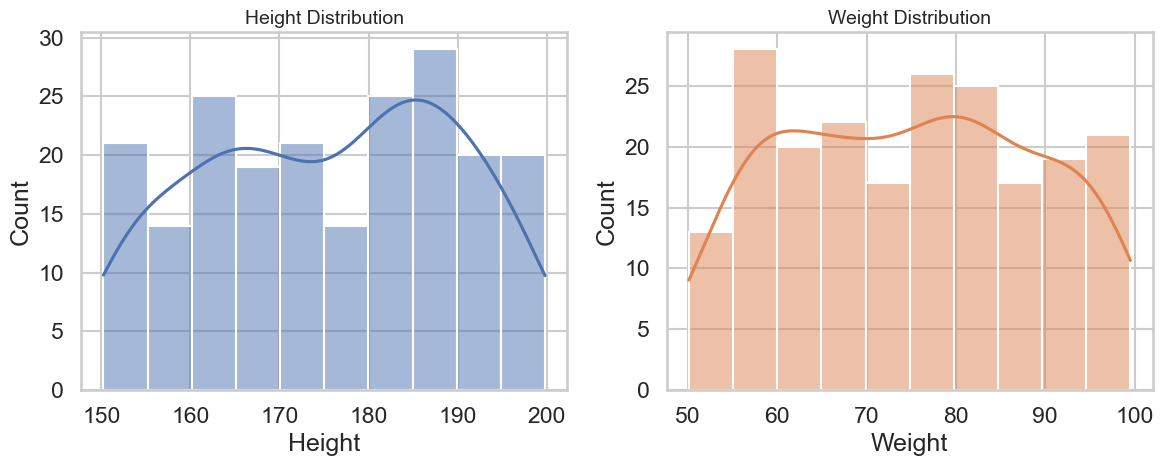

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.histplot(
    users['height'],
    bins=10,
    kde=True,
    color="#4C72B0",
    ax=axes[0]
)

axes[0].set_title("Height Distribution", fontsize=14)
axes[0].set_xlabel("Height")
axes[0].set_ylabel("Count")


sns.histplot(
    users['weight'],
    bins=10,
    kde=True,
    color="#DD8452",
    ax=axes[1]
)

axes[1].set_title("Weight Distribution", fontsize=14)
axes[1].set_xlabel("Weight")
axes[1].set_ylabel("Count")


plt.tight_layout()
plt.show()
